In [1]:
from pyspoc import Calculator, Config
from pathlib import Path
import os
import numpy as np
import pandas as pd
# Add the parent of the current script's parent to sys.path
project_root = Path('./').resolve().parents[1]

octave not found, please see README
Octave not available: octave not found, please see README
Starting JVM with java class /home/hpj22/Documents/stats_for_point_clouds/py-spoc/pyspoc/lib/jidt/infodynamics.jar.


In [2]:
my_config_yaml = f"{project_root}/notebooks/testing_summary_stats/mega_yaml.yml"

my_config_name = "new_config"
cfg = Config.from_yaml_file(my_config_name, my_config_yaml)

Registering YAML configuration file: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/notebooks/testing_summary_stats/mega_yaml.yml.
Building internal configuration.
  ✔ Module pyspoc.statistics.basic loaded successfully.
    ✔ Statistic Covariance scheme 'empirical' added successfully.
/home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'canberra_distrib_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'cosine_skew_meancentroid' added successfully.
    ✔ ReducedStatistic DistanceDistributionBasicSummarize scheme 'euclidean_skew_meance

In [3]:
# key = main folder, value = sub folder, None if no need

data_files_dict = {}

data_files_dict['isotropic_gaussian_cloud'] = None

data_files_dict['gaussian_homoskedastic_blobs'] = 'k3_std1.0'

data_files_dict['randomCov_gaussian_cloud'] = None

data_files_dict['ellipsoid_homoskedastic_blobs'] = 'k3_std1.0'

data_files_dict['lmm_torusEmbedded_3D'] = 'lenscale1.0_noise0.1_torus1'

## PARSE THE ISO AND ANISO GAUSSIAN FOLDERS

filename_dict = {}

for dataset_type in data_files_dict.keys():

    n_sample = 1000
    n_feature = 100
    base_dir = os.path.join(project_root,'data','synthetic_data',dataset_type,f'N{n_sample}_P{n_feature}')

    if data_files_dict[dataset_type] is None:
        subfolder_path = base_dir
    else:
        subfolder_path = os.path.join(base_dir,data_files_dict[dataset_type])        

    meta_file = os.path.join(subfolder_path, "meta.csv")
    meta_df = pd.read_csv(meta_file)

    ## change this to take sample_num from meta_df:
    filename_dict[dataset_type] = {v.split('_')[0] : os.path.join(subfolder_path,v) for v in meta_df['filename']}

In [4]:
flat = {f"{k}_{sk}": sv for k, v in filename_dict.items() for sk, sv in v.items()}

In [5]:
# len(flat.keys())

In [6]:
# from scipy.stats import skew, kurtosis
# from scipy.spatial.distance import cdist,pdist
# dist_distr = pdist(sample_X, metric = 'euclidean')
# kurt = np.mean(dist_distr)
# type(kurt)

In [7]:
res_dict = {}

for sample_file in flat.keys():

    print(sample_file)

    sample_X = np.load(flat[sample_file])

    calc = Calculator(sample_X)
    calc.compute(cfg)
    results = calc.results

    res_dict[sample_file] = results

    # break

isotropic_gaussian_cloud_sample0
Normalising the dataset using StandardScaler 



Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|██████████| 1/1 [00:00<00:00, 23.56it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenEntropy.eigen_entropy]: 100%|██████████| 3/3 [00:00<00:00, 12.69it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid]:  82%|████████▏ | 9/11 [00:00<00:00, 54.52it/s] 

Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid]: 100%|██████████| 11/11 [00:00<00:00, 47.29it/s]



Calculation complete. Time taken: 0.5143s
isotropic_gaussian_cloud_sample1
Normalising the dataset using StandardScaler 



Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|██████████| 1/1 [00:00<00:00, 74.86it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenEntropy.eigen_entropy]: 100%|██████████| 3/3 [00:00<00:00, 163.32it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid]: 100%|██████████| 11/11 [00:00<00:00, 102.13it/s]


...

Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.euclidean_peaks_meancentroid]:  64%|██████▎   | 7/11 [00:00<00:00, 53.39it/s]

Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid]: 100%|██████████| 11/11 [00:00<00:00, 40.04it/s]



Calculation complete. Time taken: 0.3180s
lmm_torusEmbedded_3D_sample9
Normalising the dataset using StandardScaler 



Processing [None: pyspoc.statistics.basic.Covariance.empirical]: 100%|██████████| 1/1 [00:00<00:00, 80.98it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/feature_covariance_stats.py.EigenEntropy.eigen_entropy]: 100%|██████████| 3/3 [00:00<00:00, 102.58it/s]
Processing [None: /home/hpj22/Documents/stats_for_point_clouds/py-spoc/working_analyses/hjResearch_2025/summary_stats/distance_distrib_stats.py.DistanceDistributionModesSummarize.canberra_peaks_meancentroid]: 100%|██████████| 11/11 [00:00<00:00, 79.70it/s]











Calculation complete. Time taken: 0.1828s


In [8]:
print('done!')

done!


In [9]:
concat_res = pd.concat(res_dict).reset_index()
concat_res['data_type'] = concat_res['level_0'].map(lambda v : '_'.join(v.split('_')[:-1]))
concat_res = concat_res.set_index([('level_0', ''),('level_1', ''),('data_type', '')])

In [10]:
# concat_res

In [11]:
from sklearn.decomposition import PCA
pca = PCA(n_components=min(concat_res.shape[0],concat_res.shape[1]))
# pca.fit(concat_res)

In [12]:
res_pca = pca.fit_transform(concat_res)

In [13]:
res_pca.shape

(50, 22)

In [14]:
# dtype_lst = list(concat_res.T.columns.get_level_values(2))

In [15]:
unique_dtypes = concat_res.T.columns.get_level_values(2).unique()
unique_dtype_dict = dict(zip(unique_dtypes,[i for i in range(len(unique_dtypes))]))

In [16]:
# dtype_lst = [unique_dtype_dict[v] for v in concat_res.T.columns.get_level_values(2)]
dtype_lst = [v for v in concat_res.T.columns.get_level_values(2)]

In [17]:
from matplotlib import pyplot as plt

In [18]:
plot_df = pd.DataFrame({ 'pc0' : res_pca[:,0], 'pc1' : res_pca[:,1], 'dtype' : dtype_lst})

In [19]:
import seaborn as sns

Text(0.5, 1.0, 'pca of dataset-embedding space, N = 1000, P = 100')

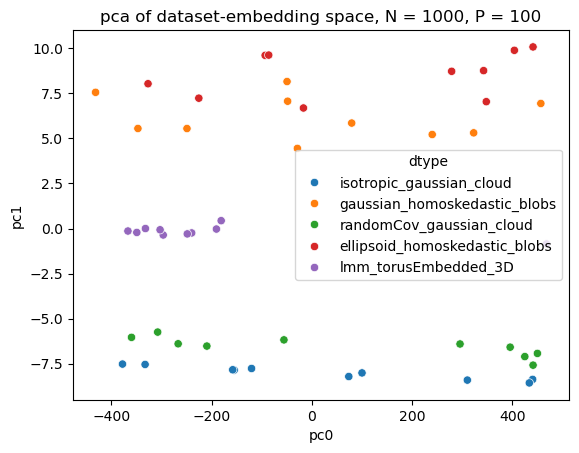

In [20]:
sns.scatterplot(plot_df,x='pc0', y = 'pc1', hue = 'dtype')
plt.title('pca of dataset-embedding space, N = 1000, P = 100')

In [21]:
summed_var = np.cumsum(pca.explained_variance_ratio_)

In [33]:
summed_var

array([0.99944843, 0.99993682, 0.99997617, 0.99998685, 0.9999918 ,
       0.99999495, 0.99999735, 0.99999825, 0.99999902, 0.99999946,
       0.99999977, 0.99999993, 0.99999997, 0.99999999, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])

In [32]:
np.linspace(0,1,len(summed_var))

array([0.        , 0.04761905, 0.0952381 , 0.14285714, 0.19047619,
       0.23809524, 0.28571429, 0.33333333, 0.38095238, 0.42857143,
       0.47619048, 0.52380952, 0.57142857, 0.61904762, 0.66666667,
       0.71428571, 0.76190476, 0.80952381, 0.85714286, 0.9047619 ,
       0.95238095, 1.        ])

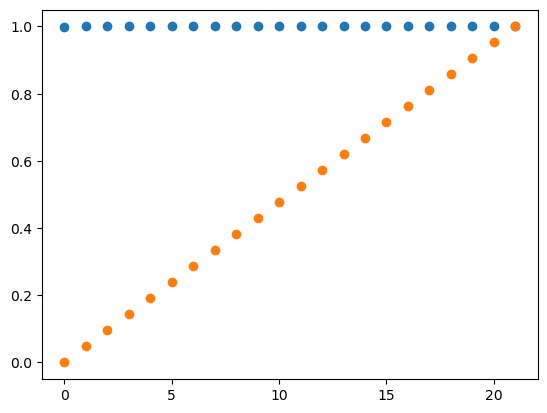

In [27]:
plt.scatter(y = summed_var, x = range(len(summed_var)))
plt.scatter(y = np.linspace(0,1,len(summed_var)), x = range(len(summed_var)))